# 1. 모델 불러오기

In [3]:
import torch

print(torch.__version__)

2.10.0+cu126


In [6]:
from ultralytics import YOLO

model = YOLO('./models/yolo26n-seg.pt')

# 2. 예측하기

In [9]:
img_url = 'https://ultralytics.com/images/bus.jpg'
img_path = './images/dog.jpeg'

results = model.predict(
    source=img_url,
    save=True,
    project='myresult'
)


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 c:\potenup3\03-utilizing-huggingface\bus.jpg: 640x480 4 persons, 1 bus, 56.4ms
Speed: 3.4ms preprocess, 56.4ms inference, 6.5ms postprocess per image at shape (1, 3, 640, 480)
Results saved to C:\potenup3\03-utilizing-huggingface\runs\segment\myresult\predict3


In [10]:
result = results[0]
result

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair

In [11]:
result.masks

ultralytics.engine.results.Masks object with attributes:

data: tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0

In [13]:
print(f'len(result.masks.data): {len(result.masks.data)}')
print(f'result.masks.data[0].shape: {result.masks.data[0].shape}')
result.masks.data[0]

len(result.masks.data): 5
result.masks.data[0].shape: torch.Size([640, 480])


tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], device='cuda:0', dtype=torch.uint8)

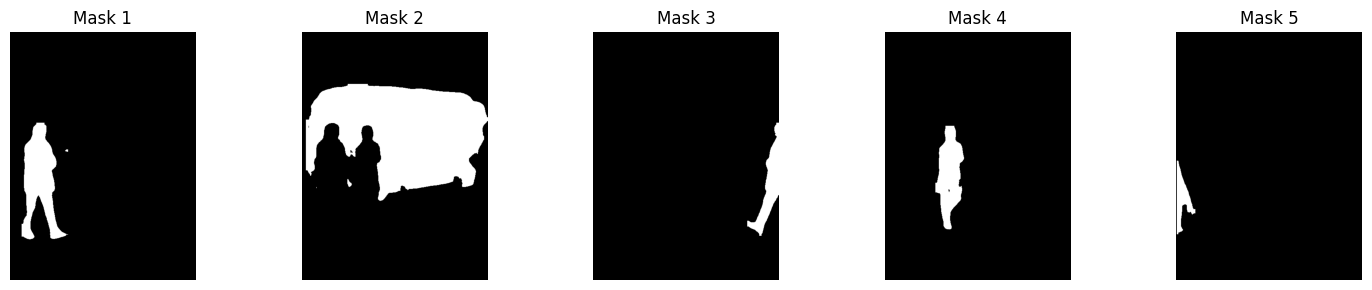

In [28]:
import matplotlib.pyplot as plt
import math

# GPU에 있는 텐서 데이터를 CPU로 옮기고 Numpy 배열로 변환
masks = result.masks.data.cpu().numpy()
num_masks = len(masks)

# 격자(Grid) 크기 계산 (최대 4열)
cols = min(5, num_masks)
rows = math.ceil(num_masks / cols)

# Subplots 생성
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

# 축(axes)을 1차원 리스트로 평탄화 (인덱싱을 쉽게 하기 위함)
if num_masks > 1:
    axes = axes.flatten()
else:
    axes = [axes] # 마스크가 1개일 경우를 대비한 예외 처리

for idx in range(num_masks):
    axes[idx].imshow(masks[idx], cmap='gray')
    axes[idx].axis("off")
    axes[idx].set_title(f"Mask {idx + 1}")

# 데이터가 없는 빈 subplot의 축 숨기기
for idx in range(num_masks, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

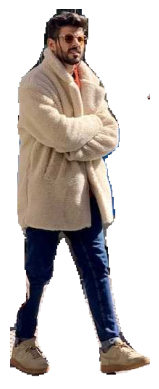

In [31]:
import numpy as np
from PIL import Image

idx = 0

# 1) 원본 이미지 numpy로 바꾸기 ( RGB -> BGR )
orig = Image.fromarray(result.orig_img[:,:,::-1])

# 2) 마스크, 원본 이미지 사이즈로 리사이즈
masks = result.masks
mask = masks.data[idx].to('cpu').numpy()
mask_resized = Image.fromarray(
    (mask * 255).astype(np.uint8)).resize(
    (orig.width, orig.height),
    Image.NEAREST
)

# 3) ALPHA 채널 추가 및 마스크 적용
orig_rgba = orig.convert('RGBA')
orig_array = np.array(orig_rgba)
orig_array[:,:,3] = np.array(mask_resized)
masked_img = Image.fromarray(orig_array)

# 4) 박스 크롭
x1, y1, x2, y2 = result.boxes.xyxy[idx].int().tolist()
crop_img = masked_img.crop((x1, y1, x2, y2))

# 5) 이미지 출력
plt.imshow(crop_img)
plt.axis('off')
plt.show()

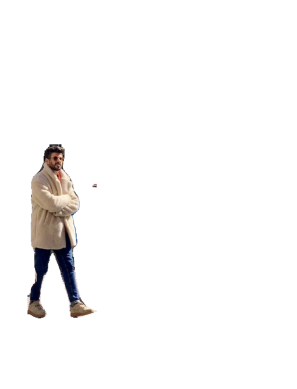

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

idx = 0

# 1. 원본 이미지를 불러와 바로 RGBA로 변환
orig = Image.fromarray(result.orig_img[:, :, ::-1]).convert('RGBA')

# 2. 마스크 데이터를 가져와 PIL 이미지로 변환 및 리사이즈
mask_data = result.masks.data[idx].cpu().numpy()
mask_img = Image.fromarray((mask_data * 255).astype(np.uint8))
mask_resized = mask_img.resize(orig.size, Image.NEAREST)

# 3. 투명도(Alpha) 채널에 마스크 바로 덮어쓰기 (Numpy 병합 불필요)
orig.putalpha(mask_resized)

# 4. 결과 출력
plt.imshow(orig)
plt.axis('off')
plt.show()

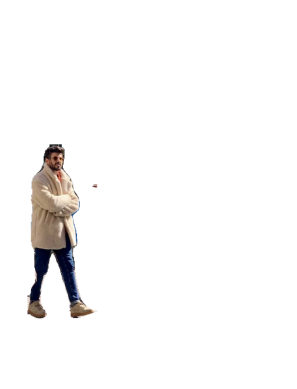

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

idx = 0

# 1. 원본 이미지(BGR -> RGB) 및 마스크 추출
orig_rgb = result.orig_img[:, :, ::-1]
mask_data = result.masks.data[idx].cpu().numpy()

# 2. OpenCV를 사용한 고속 리사이즈 (PIL보다 빠름)
h, w = orig_rgb.shape[:2]
mask_resized = cv2.resize(mask_data, (w, h), interpolation=cv2.INTER_NEAREST)

# 3. 알파 채널 생성 (0 or 255)
alpha_channel = (mask_resized * 255).astype(np.uint8)

# 4. RGB와 Alpha 채널을 결합하여 RGBA 생성 (np.dstack 활용)
rgba_img = np.dstack((orig_rgb, alpha_channel))

# 5. 결과 출력
plt.imshow(rgba_img)
plt.axis('off')
plt.show()

In [34]:
result.boxes.cls

tensor([0., 5., 0., 0., 0.], device='cuda:0')

In [35]:
names = result.names
print(names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [38]:
pred_idx_list = result.boxes.cls

for pred_idx in pred_idx_list:
    print(int(pred_idx.to('cpu')))
    print(names[int(pred_idx.to('cpu'))])
    print('-'*50)

0
person
--------------------------------------------------
5
bus
--------------------------------------------------
0
person
--------------------------------------------------
0
person
--------------------------------------------------
0
person
--------------------------------------------------


# FastSAM

## 1) 모델 불러오기

In [39]:
from ultralytics import FastSAM

model = FastSAM('./models/FastSAM-s.pt')
model

FastSAM(
  (model): SegmentationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_run

## 2) 예측하기

In [43]:
source = './images/dog.jpeg'

results = model.predict(
    source=source,
    save=True,
    project='myresult'
)


image 1/1 c:\potenup3\03-utilizing-huggingface\images\dog.jpeg: 640x384 50 objects, 75.4ms
Speed: 3.0ms preprocess, 75.4ms inference, 40.8ms postprocess per image at shape (1, 3, 640, 384)
Results saved to C:\potenup3\03-utilizing-huggingface\runs\segment\myresult\predict5


In [44]:
print(type(results))
print(len(results))

<class 'list'>
1


## 3) 텍스트와 이미지로 예측하기

In [49]:
results = model.predict(
    source=source,
    texts='a dog',
    save=True,
    project='myresult'
)


image 1/1 c:\potenup3\03-utilizing-huggingface\images\dog.jpeg: 640x384 1 object, 57.1ms
Speed: 3.4ms preprocess, 57.1ms inference, 641.1ms postprocess per image at shape (1, 3, 640, 384)
Results saved to C:\potenup3\03-utilizing-huggingface\runs\segment\myresult\predict7


In [50]:
result = results[0]
len(result.masks.data)

1

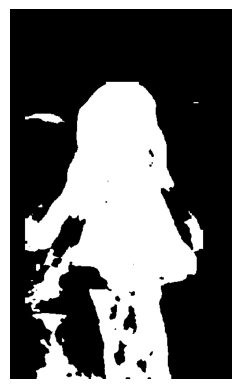

In [51]:
import matplotlib.pyplot as plt

idx = 0

plt.imshow(result.masks.data[idx].to('cpu'), cmap='gray')
plt.axis('off')
plt.show()

In [72]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def extract_all_objects_transparent(result):
    """
    YOLOv8/v11 result 객체에서 모든 객체를 투명 배경으로 추출합니다.
    """
    extracted_images = []
    
    # 1. 원본 이미지 가져오기 및 RGBA 변환
    # result.orig_img는 BGR 순서이므로 RGB로 바꾸고 PIL Image로 변환
    orig_img_rgb = Image.fromarray(result.orig_img[:, :, ::-1]).convert('RGBA')
    orig_w, orig_h = orig_img_rgb.size

    # 마스크 데이터가 없으면 빈 리스트 반환
    if result.masks is None:
        print("No masks found in the result.")
        return []

    # 2. 모든 마스크 순회 (enumerate 활용)
    for idx, mask_tensor in enumerate(result.masks.data):
        # 마스크 데이터를 CPU로 이동하여 Numpy 배열로 변환
        mask_np = mask_tensor.cpu().numpy()

        # 3. 마스크 리사이즈 및 이진화 (NEAREST interpolation)
        # (orig_w, orig_h) 순서로 인자를 넣어야 함
        mask_img = Image.fromarray((mask_np * 255).astype(np.uint8))
        mask_resized = mask_img.resize((orig_w, orig_h), Image.NEAREST)

        # 4. 객체 추출 (Alpha 채널 적용)
        # 원본의 복사본을 만들고 putalpha를 사용하여 배경 투명화
        obj_img = orig_img_rgb.copy()
        obj_img.putalpha(mask_resized)
        
        # 4) 박스 크롭
        x1, y1, x2, y2 = result.boxes.xyxy[idx].int().tolist()
        crop_img = obj_img.crop((x1, y1, x2, y2))
        
        # (선택 사항) 객체 주변의 불필요한 투명 여백을 잘라내고 싶다면 아래 주석 해제
        # obj_img = obj_img.crop(obj_img.getbbox())

        extracted_images.append(crop_img)
        print(f"Extracted object {idx + 1}/{len(result.masks.data)}")

    return extracted_images

# --- 사용 예시 ---
# 'result' 변수에 YOLO 모델의 예측 결과가 담겨 있다고 가정합니다.
# example: result = model('image.jpg')[0]

Extracted object 1/1


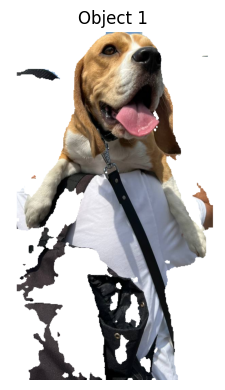

In [73]:

object_images = extract_all_objects_transparent(result)

# 결과 확인 (Matplotlib으로 격자 출력)
if object_images:
    num_objects = len(object_images)
    cols = min(3, num_objects)
    rows = (num_objects + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten() if num_objects > 1 else [axes]
    
    for i, img in enumerate(object_images):
        axes[i].imshow(img)
        axes[i].set_title(f"Object {i+1}")
        axes[i].axis('off')
        
    # 남는 subplot 숨기기
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

# SAM3

## 0) 준비과정
* 허깅페이스 로그인
* 모델 다운로드

In [55]:
# uv add python-dotenv huggingface_hub
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [56]:
from huggingface_hub import login
import os

login(token=os.getenv("HUGGINGFACE_TOKEN"))

## 1) 모델 불러오기

In [57]:
from huggingface_hub import hf_hub_download

hf_hub_download(
    repo_id='facebook/sam3',
    filename='sam3.pt',
    local_dir='./models',
    token=os.getenv('HUGGINGFACE_TOKEN')
)

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

'models\\sam3.pt'

## 2) 예측하기

In [61]:
from ultralytics.models.sam import SAM3SemanticPredictor

overrides = dict(
    conf=0.25,
    task='segment',
    mode='predict',
    model='./models/sam3.pt',
    half=True,
    save=True
)

predictor = SAM3SemanticPredictor(overrides=overrides)

In [63]:
predictor.set_image('./images/test_image.jpg')

WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]


In [69]:
results = predictor(text=['a person in red clothes'])


image 1/1 c:\potenup3\03-utilizing-huggingface\images\test_image.jpg: 644x644 3 a person in red clothess, 339.3ms
Speed: 6.6ms preprocess, 339.3ms inference, 8.4ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\potenup3\03-utilizing-huggingface\runs\segment\predict


Extracted object 1/3
Extracted object 2/3
Extracted object 3/3


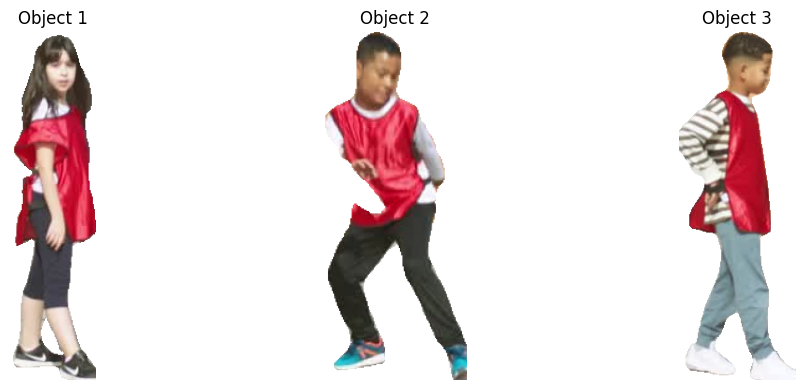

In [74]:
object_images = extract_all_objects_transparent(results[0])

# 결과 확인 (Matplotlib으로 격자 출력)
if object_images:
    num_objects = len(object_images)
    cols = min(3, num_objects)
    rows = (num_objects + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten() if num_objects > 1 else [axes]
    
    for i, img in enumerate(object_images):
        axes[i].imshow(img)
        axes[i].set_title(f"Object {i+1}")
        axes[i].axis('off')
        
    # 남는 subplot 숨기기
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()